# PhaseAware Optimizer Experiments

This notebook evaluates PhaseAware against standard optimization baselines.

Experiments include:

1. Training stability verification
2. Phase schedule ablation
3. Exploration noise ablation
4. Multi-optimizer comparison

Baselines:
- SGD + Momentum
- Adam
- AdamW

Metrics:
- Validation accuracy
- Training loss
- Convergence speed
- Phase evolution
- Learning rate schedule
- Noise magnitude

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import random
import time
import matplotlib.pyplot as plt

from functools import partial

from optimizer import PhaseAwareOptimizer

In [2]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [4]:
from datasets import load_dataset


dataset = load_dataset(
    "ag_news"
)


print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [5]:
from collections import Counter


def tokenize(text):
    return text.lower().split()



def build_vocab(dataset, max_size=30000):

    counter = Counter()

    for item in dataset:
        counter.update(
            tokenize(item["text"])
        )


    vocab = {
        "<PAD>":0,
        "<UNK>":1
    }


    for word, _ in counter.most_common(max_size):

        vocab[word] = len(vocab)


    return vocab

In [6]:
vocab = build_vocab(
    dataset["train"]
)


print(
    "Vocabulary:",
    len(vocab)
)

Vocabulary: 30002


In [7]:
class SmallTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        num_classes=4,
        d_model=128,
        n_heads=4,
        n_layers=2,
        max_len=128,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=0
        )

        self.pos_emb = nn.Embedding(
            max_len,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            d_model,
            num_classes
        )


    def forward(self, x):

        padding_mask = (
            x == 0
        )


        seq_len = x.size(1)

        positions = torch.arange(
            seq_len,
            device=x.device
        ).unsqueeze(0)


        x = (
            self.embedding(x)
            +
            self.pos_emb(positions)
        )


        x = self.dropout(x)


        x = self.transformer(
            x,
            src_key_padding_mask=padding_mask
        )


        x = x[:,0,:]


        return self.classifier(x)

In [8]:
from torch.utils.data import Dataset, DataLoader


class AGNewsDataset(Dataset):

    def __init__(self, split, vocab, max_len=128):

        self.data = split
        self.vocab = vocab
        self.max_len = max_len


    def encode(self, text):

        tokens = text.lower().split()

        ids = [
            self.vocab.get(t, 1)
            for t in tokens[:self.max_len]
        ]

        if len(ids) < self.max_len:
            ids += [0] * (self.max_len - len(ids))

        return torch.tensor(
            ids,
            dtype=torch.long
        )


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):

        item = self.data[idx]

        return (
            self.encode(item["text"]),
            torch.tensor(
                item["label"],
                dtype=torch.long
            )
        )

In [9]:
train_dataset = AGNewsDataset(
    dataset["train"],
    vocab
)

test_dataset = AGNewsDataset(
    dataset["test"],
    vocab
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=64
)


print(
    len(train_loader),
    len(test_loader)
)

1875 119


In [ ]:
def train(
    optimizer_name,
    epochs=15,
    seed=47
):

    set_seed(seed)


    model = SmallTransformer(
        len(vocab)
    ).to(device)


    if optimizer_name=="PhaseAware":

        optimizer = PhaseAwareOptimizer(
            model.parameters(),

            lr_max=0.01,
            lr_min=0.001,

            noise_max=0.05,

            total_steps=len(train_loader) * epochs,

            warmup_ratio=0.10,

            phase_type="time",

            weight_decay=1e-4,
        )


    elif optimizer_name=="Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=1e-3,
            #weight_decay=1e-4
        )


    elif optimizer_name=="SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=0.01,
            momentum=0.9,
            weight_decay=1e-4
        )


    history = {
        "loss":[],
        "phase":[],
        "lr":[]
    }


    criterion = nn.CrossEntropyLoss()


    for epoch in range(epochs):

        model.train()

        epoch_loss=0


        for x,y in train_loader:

            x=x.to(device)
            y=y.to(device)


            optimizer.zero_grad()


            out=model(x)

            loss=criterion(out,y)


            loss.backward()

            optimizer.step()


            epoch_loss += loss.item()



        history["loss"].append(
            epoch_loss/len(train_loader)
        )


        if optimizer_name=="PhaseAware":

            state=optimizer.get_current_state()

            history["phase"].append(
                state["phase"]
            )

            history["lr"].append(
                state["lr"]
            )


        print(
            epoch,
            history["loss"][-1]
        )


    return history

In [13]:
seeds = [762, 123, 456]

results = {}


for opt in [
    "SGD",
    "Adam",
    "PhaseAware"
]:

    print("\n====================")
    print("Optimizer:", opt)
    print("====================")


    results[opt] = []


    for seed in seeds:

        print(
            "Seed:",
            seed
        )


        history = train(
            opt,
            seed=seed
        )


        results[opt].append(
            history
        )


Optimizer: SGD
Seed: 762
0 1.2387399288654328
1 0.7369567566553752
2 0.5693296746492386
3 0.4897758721232414
4 0.4306309490442276
5 0.38675752248366674
6 0.34998941469589867
7 0.3253549724201361
8 0.3031140793601672
9 0.2790169768412908
10 0.2660534586807092
11 0.25652253831028937
12 0.24089831999142966
13 0.23471947476069133
14 0.22656947524348894
Seed: 123
0 nan
1 nan
2 nan
3 nan
4 nan
5 nan
6 nan
7 nan
8 nan
9 nan
10 nan
11 nan
12 nan
13 nan
14 nan
Seed: 456
0 nan
1 nan
2 nan
3 nan
4 nan
5 nan
6 nan
7 nan
8 nan
9 nan
10 nan
11 nan
12 nan
13 nan
14 nan

Optimizer: Adam
Seed: 762
0 0.5675529611666997
1 0.3074918810129166
2 0.23846590481201807
3 0.19924177460968495
4 0.1681100552181403
5 0.14500916146735351
6 0.12270943148930867
7 0.1076994196643432
8 0.09422040000632405
9 0.08221322054875393
10 0.07297767558544874
11 0.06453963204212487
12 0.057040122991986575
13 0.05118412543376908
14 0.04650383676309139
Seed: 123
0 0.5672354790210724
1 0.30647948474089304
2 0.23762507604559263
3 0.

In [14]:
summary = {}


for opt, runs in results.items():

    final_losses = [
        run["loss"][-1]
        for run in runs
    ]


    mean_loss = np.mean(final_losses)

    std_loss = np.std(final_losses)


    summary[opt] = {
        "mean": mean_loss,
        "std": std_loss,
        "runs": final_losses
    }


for opt, data in summary.items():

    print(
        f"{opt}: "
        f"{data['mean']:.5f} ± {data['std']:.5f}"
    )

SGD: nan ± nan
Adam: 0.04582 ± 0.00052
PhaseAware: 0.00690 ± 0.00017


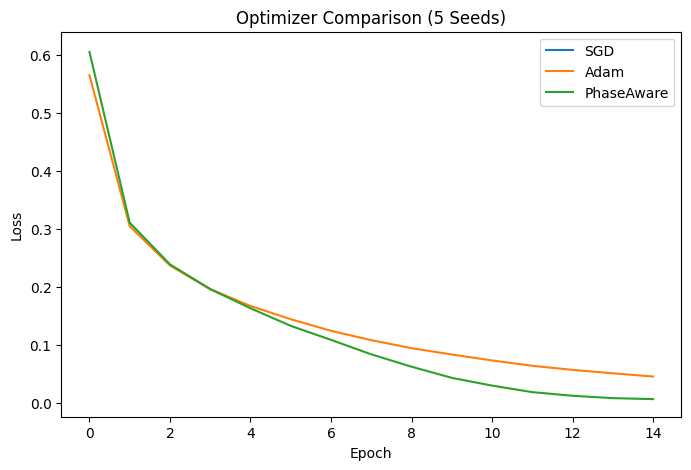

In [15]:
plt.figure(figsize=(8,5))


for opt, runs in results.items():

    losses = np.array([
        run["loss"]
        for run in runs
    ])


    mean_curve = losses.mean(axis=0)


    std_curve = losses.std(axis=0)


    epochs = range(len(mean_curve))


    plt.plot(
        epochs,
        mean_curve,
        label=opt
    )


    plt.fill_between(
        epochs,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.2
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Optimizer Comparison (5 Seeds)"
)

plt.legend()
plt.show()

In [16]:
def plot_mean_curve(
    runs,
    key,
    title,
    ylabel
):

    values = np.array([
        run[key]
        for run in runs
    ])

    mean = values.mean(axis=0)
    std = values.std(axis=0)

    epochs = range(len(mean))


    plt.figure(figsize=(8,4))


    plt.plot(
        epochs,
        mean
    )


    plt.fill_between(
        epochs,
        mean - std,
        mean + std,
        alpha=0.2
    )


    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    plt.title(title)

    plt.show()

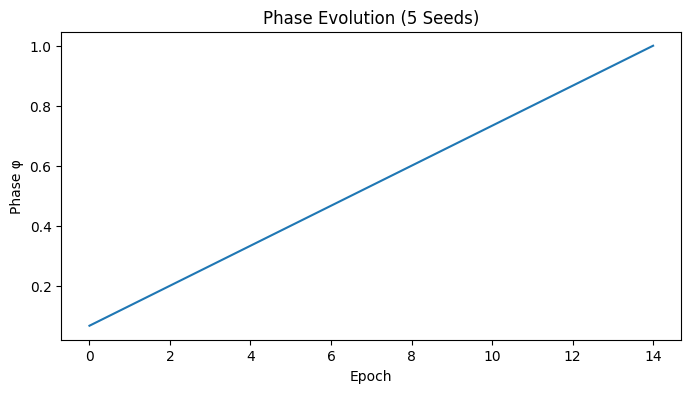

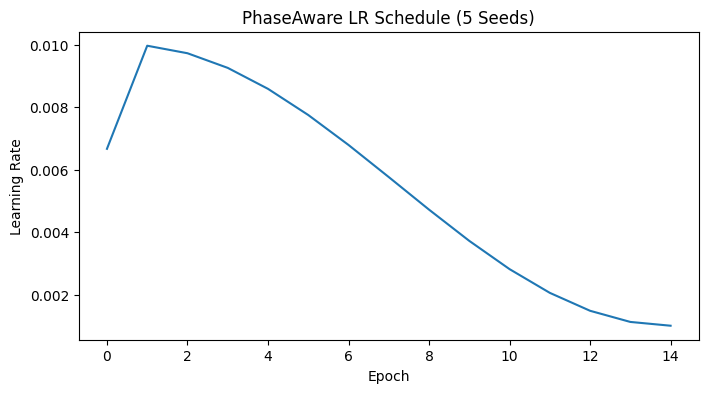

KeyError: 'noise'

In [17]:
plot_mean_curve(
    results["PhaseAware"],
    "phase",
    "Phase Evolution (5 Seeds)",
    "Phase φ"
)


plot_mean_curve(
    results["PhaseAware"],
    "lr",
    "PhaseAware LR Schedule (5 Seeds)",
    "Learning Rate"
)


plot_mean_curve(
    results["PhaseAware"],
    "noise",
    "PhaseAware Noise Schedule (5 Seeds)",
    "Noise Magnitude"
)